# NBA Game Prediction System
## Dense Neural Network + TabPFN Approach

**Models built:**
1. Dense NN (Keras) — Win/Loss classification
2. Dense NN (Keras) — Points regression (for spreads)
3. TabPFN — Win/Loss classification
4. TabPFN — Points regression

**Features engineered:**
- Rolling shooting percentages (FG%, 3P%, FT%)
- Rolling offensive/defensive stats (PTS, REB, AST, STL, BLK, TOV)
- Last 10 games form (win count)
- Missing player impact (USG%, PPG of absent key players)
- Home/away indicator

**Based on:** TabPFN (Hollmann et al., Nature 2025) and stacked ensemble approach (He & Choi, Scientific Reports 2025)

## 1. Setup & Install

In [ ]:
!pip install -q nba_api pandas numpy scikit-learn matplotlib seaborn
!pip install -q tensorflow
!pip install -q tabpfn
print('All packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 29.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.9/226.9 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
All packages installed


## 2. Mount Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
DATA_DIR = '/content/drive/MyDrive/Modern AI Final Project/nba_data_2'
print('Files:', os.listdir(DATA_DIR))

Files: ['player_pergame.csv', 'player_advanced.csv', 'team_standings.csv', 'box_scores.csv', 'models', 'team_game_features.csv', 'matchup_features.csv']


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

box = pd.read_csv(os.path.join(DATA_DIR, 'box_scores.csv'), low_memory=False)
advanced = pd.read_csv(os.path.join(DATA_DIR, 'player_advanced.csv'))
pergame = pd.read_csv(os.path.join(DATA_DIR, 'player_pergame.csv'))
standings = pd.read_csv(os.path.join(DATA_DIR, 'team_standings.csv'))

print(f'box_scores:      {len(box):>9,} rows')
print(f'player_advanced: {len(advanced):>9,} rows')
print(f'player_pergame:  {len(pergame):>9,} rows')
print(f'team_standings:  {len(standings):>9,} rows')
print()
print('Box score columns:', box.columns.tolist())
print('Seasons:', box['SEASON'].unique())

box_scores:        131,292 rows
player_advanced:     2,867 rows
player_pergame:      2,867 rows
team_standings:        150 rows

Box score columns: ['GAME_ID', 'PLAYER_ID', 'PLAYER_NAME', 'TEAM', 'MIN', 'PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'FGA', 'FGM', '3PA', '3PM', 'FTA', 'FTM', 'PLUS_MINUS', 'HOME_TEAM', 'AWAY_TEAM', 'HOME_PTS', 'AWAY_PTS', 'SEASON']
Seasons: ['2021-22' '2022-23' '2023-24' '2024-25' '2025-26']


## 3. Feature Engineering
### 3a. Aggregate box scores to team-game level

In [ ]:
# Aggregate per-player box scores into per-team-per-game totals
team_game = box.groupby(['GAME_ID','TEAM', 'SEASON']).agg(
    FGM=('FGM', 'sum'),
    FGA=('FGA', 'sum'),
    TPM=('3PM', 'sum'),
    TPA=('3PA', 'sum'),
    FTM=('FTM', 'sum'),
    FTA=('FTA', 'sum'),
    REB=('REB', 'sum'),
    AST=('AST', 'sum'),
    STL=('STL', 'sum'),
    BLK=('BLK', 'sum'),
    TOV=('TOV', 'sum'),
    PTS=('PTS', 'sum'),
    PLUS_MINUS=('PLUS_MINUS', 'sum'),
    HOME_TEAM=('HOME_TEAM', 'first'),
    AWAY_TEAM=('AWAY_TEAM', 'first'),
    HOME_PTS=('HOME_PTS', 'first'),
    AWAY_PTS=('AWAY_PTS', 'first'),
    NUM_PLAYERS=('PLAYER_ID', 'count'),
).reset_index()

# Calculate shooting percentages for this game
team_game['FG_PCT'] = (team_game['FGM'] / team_game['FGA'].replace(0, np.nan)).fillna(0)
team_game['TP_PCT'] = (team_game['TPM'] / team_game['TPA'].replace(0, np.nan)).fillna(0)
team_game['FT_PCT'] = (team_game['FTM'] / team_game['FTA'].replace(0, np.nan)).fillna(0)

# Calculate 2-point stats (important per the He & Choi paper)
team_game['TWO_PM'] = team_game['FGM'] - team_game['TPM']
team_game['TWO_PA'] = team_game['FGA'] - team_game['TPA']
team_game['TWO_PCT'] = (team_game['TWO_PM'] / team_game['TWO_PA'].replace(0, np.nan)).fillna(0)

# Determine win/loss
team_game['IS_HOME'] = (team_game['TEAM'] == team_game['HOME_TEAM']).astype(int)
team_game['OPP_TEAM'] = np.where(team_game['IS_HOME'] == 1, team_game['AWAY_TEAM'], team_game['HOME_TEAM'])
team_game['OPP_PTS'] = np.where(team_game['IS_HOME'] == 1, team_game['AWAY_PTS'], team_game['HOME_PTS'])
team_game['WIN'] = (team_game['PTS'] > team_game['OPP_PTS']).astype(int)

# Sort chronologically per team
team_game = team_game.sort_values(['TEAM', 'SEASON', 'GAME_ID']).reset_index(drop=True)

print(f'Team-game rows: {len(team_game):,}')
print(f'Unique games: {team_game["GAME_ID"].nunique():,}')
team_game.head(3)

Team-game rows: 12,300
Unique games: 6,150


,GAME_ID,TEAM,SEASON,FGM,FGA,TPM,TPA,FTM,FTA,REB,...,FG_PCT,TP_PCT,FT_PCT,TWO_PM,TWO_PA,TWO_PCT,IS_HOME,OPP_TEAM,OPP_PTS,WIN
0,22100014,ATL,2021-22,45,94,15,35,8,9,55,...,0.478723,0.428571,0.888889,30,59,0.508475,1,DAL,87.0,1
1,22100027,ATL,2021-22,38,99,10,34,9,15,54,...,0.383838,0.294118,0.600000,28,65,0.430769,0,CLE,101.0,0
2,22100043,ATL,2021-22,46,90,12,32,18,21,49,...,0.511111,0.375000,0.857143,34,58,0.586207,1,DET,104.0,1


### 3b. Rolling averages (pre-game stats — no data leakage)

In [ ]:
ROLLING_WINDOW = 10
roll_cols = ['PTS', 'FGM', 'FGA', 'FG_PCT', 'TPM', 'TPA', 'TP_PCT',
             'TWO_PM', 'TWO_PA', 'TWO_PCT', 'FTM', 'FTA', 'FT_PCT',
             'REB', 'AST', 'STL', 'BLK', 'TOV']

for col in roll_cols:
    team_game[f'R_{col}'] = (
        team_game.groupby(['TEAM', 'SEASON'])[col]
        .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=3).mean())
    )

team_game['LAST10_WINS'] = (
    team_game.groupby(['TEAM', 'SEASON'])['WIN']
    .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=3).sum())
)


team_game_clean = team_game.dropna(subset=[f'R_{roll_cols[0]}', 'LAST10_WINS']).copy()
print(f'Rows after dropping early-season NaN: {len(team_game_clean):,}')
print(f'Rolling features: {[c for c in team_game_clean.columns if c.startswith("R_")][:5]} ...')

Rows after dropping early-season NaN: 11,850
Rolling features: ['R_PTS', 'R_FGM', 'R_FGA', 'R_FG_PCT', 'R_TPM'] ...


### 3c. Missing player impact

In [ ]:

MIN_GP = 15
KEY_USG = 18.0
KEY_PPG = 12.0

stats = pergame[['PLAYER_ID', 'PLAYER_NAME', 'TEAM', 'GP', 'PPG', 'SEASON']].merge(
    advanced[['PLAYER_ID', 'TEAM', 'USG_PCT', 'PIE', 'SEASON']],
    on=['PLAYER_ID', 'TEAM', 'SEASON'], how='left'
)
stats = stats[stats['GP'] >= MIN_GP].copy()
stats['IS_KEY'] = (stats['USG_PCT'].fillna(0) >= KEY_USG) | (stats['PPG'].fillna(0) >= KEY_PPG)

# build roster lookup
roster_lookup = stats.groupby(['TEAM', 'SEASON'])['PLAYER_ID'].apply(set).to_dict()

# build stats lookup
stats_lookup = {}
for _, row in stats.iterrows():
    key = (row['PLAYER_ID'], row['TEAM'], row['SEASON'])
    stats_lookup[key] = {'PPG': row['PPG'], 'USG_PCT': row['USG_PCT'] or 0,
                         'IS_KEY': row['IS_KEY']}

# player lookup
played_lookup = box.groupby(['GAME_ID', 'TEAM'])['PLAYER_ID'].apply(set).to_dict()

# Calculate missing impact
missing_usg = []
missing_ppg = []
missing_key_count = []

for _, row in team_game_clean.iterrows():
    team, season, gid = row['TEAM'], row['SEASON'], row['GAME_ID']
    roster = roster_lookup.get((team, season), set())
    played = played_lookup.get((gid, team), set())
    missing = roster - played

    m_usg, m_ppg, m_key = 0.0, 0.0, 0
    for pid in missing:
        s = stats_lookup.get((pid, team, season))
        if s:
            m_usg += s['USG_PCT']
            m_ppg += s['PPG']
            if s['IS_KEY']: m_key += 1
    missing_usg.append(m_usg)
    missing_ppg.append(m_ppg)
    missing_key_count.append(m_key)

team_game_clean['MISSING_USG'] = missing_usg
team_game_clean['MISSING_PPG'] = missing_ppg
team_game_clean['MISSING_KEY_COUNT'] = missing_key_count

print(f'Games with key players missing: {(team_game_clean["MISSING_KEY_COUNT"] > 0).sum():,}')
print(f'Avg missing USG when key player out: {team_game_clean[team_game_clean["MISSING_KEY_COUNT"]>0]["MISSING_USG"].mean():.1f}')

Games with key players missing: 8,457
Avg missing USG when key player out: 1.2


### 3d. Build matchup dataset (one row per game)

In [ ]:
# merge home team and away team rolling stats

feature_cols = [c for c in team_game_clean.columns if c.startswith('R_')] + \
               ['LAST10_WINS', 'MISSING_USG', 'MISSING_PPG', 'MISSING_KEY_COUNT']

home = team_game_clean[team_game_clean['IS_HOME'] == 1].copy()
away = team_game_clean[team_game_clean['IS_HOME'] == 0].copy()

home_renamed = home[['GAME_ID','SEASON', 'TEAM'] + feature_cols + ['PTS', 'WIN']].copy()
home_renamed = home_renamed.rename(columns={c: f'H_{c}' for c in feature_cols})
home_renamed = home_renamed.rename(columns={'TEAM': 'HOME_TEAM', 'PTS': 'HOME_PTS', 'WIN': 'HOME_WIN'})

away_renamed = away[['GAME_ID', 'TEAM'] + feature_cols + ['PTS']].copy()
away_renamed = away_renamed.rename(columns={c: f'A_{c}' for c in feature_cols})
away_renamed = away_renamed.rename(columns={'TEAM': 'AWAY_TEAM', 'PTS': 'AWAY_PTS'})


matchups = home_renamed.merge(away_renamed, on='GAME_ID', how='inner')

# calculate differential
for col in feature_cols:
    matchups[f'D_{col}'] = matchups[f'H_{col}'] - matchups[f'A_{col}']

#home court advantage indicator
matchups['HOME_ADV'] = 1

# home team spread
matchups['SPREAD'] = matchups['HOME_PTS'] - matchups['AWAY_PTS']

matchups = matchups.dropna().reset_index(drop=True)
print(f'Matchup dataset: {len(matchups):,} games')
print(f'Home win rate: {matchups["HOME_WIN"].mean():.3f}')
print(f'Features per game: {len([c for c in matchups.columns if c.startswith(("H_","A_","D_"))])}')

Matchup dataset: 5,891 games
Home win rate: 0.553
Features per game: 66


### 3e. Prepare model features

In [ ]:
# Feature sets:  differentials + individual team features
# key vars: FG, FGA, 2PA, TRB, FT, 3PA, DRB, STL, BLK

diff_features = [c for c in matchups.columns if c.startswith('D_')]
home_features = [c for c in matchups.columns if c.startswith('H_')]
away_features = [c for c in matchups.columns if c.startswith('A_')]

FEATURES = diff_features + ['HOME_ADV']

X = matchups[FEATURES].values
y_class = matchups['HOME_WIN'].values
y_home_pts = matchups['HOME_PTS'].values
y_away_pts = matchups['AWAY_PTS'].values
y_spread = matchups['SPREAD'].values

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {FEATURES[:5]} ... ({len(FEATURES)} total)')
print(f'Class balance: {y_class.mean():.3f} (home win rate)')

Feature matrix shape: (5891, 23)
Features: ['D_R_PTS', 'D_R_FGM', 'D_R_FGA', 'D_R_FG_PCT', 'D_R_TPM'] ... (23 total)
Class balance: 0.553 (home win rate)


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error

# train/test
matchups_sorted = matchups.sort_values(['SEASON', 'GAME_ID']).reset_index(drop=True)
train_end = int(len(matchups_sorted) * 0.70)
val_end = int(len(matchups_sorted) * 0.80)

X_all = matchups_sorted[FEATURES].values
y_class_all = matchups_sorted['HOME_WIN'].values
y_spread_all = matchups_sorted['SPREAD'].values
y_home_all = matchups_sorted['HOME_PTS'].values
y_away_all = matchups_sorted['AWAY_PTS'].values

X_fit, X_val, X_test = X_all[:train_end], X_all[train_end:val_end], X_all[val_end:]
y_fit_cls, y_val_cls, y_test_cls = y_class_all[:train_end], y_class_all[train_end:val_end], y_class_all[val_end:]
y_fit_spread, y_val_spread, y_test_spread = y_spread_all[:train_end], y_spread_all[train_end:val_end], y_spread_all[val_end:]
y_fit_home, y_val_home, y_test_home = y_home_all[:train_end], y_home_all[train_end:val_end], y_home_all[val_end:]
y_fit_away, y_val_away, y_test_away = y_away_all[:train_end], y_away_all[train_end:val_end], y_away_all[val_end:]

X_train = X_all[:val_end]
y_train_cls = y_class_all[:val_end]
y_train_spread = y_spread_all[:val_end]
y_train_home = y_home_all[:val_end]
y_train_away = y_away_all[:val_end]

# ccale features for neural nets
scaler = StandardScaler()
X_fit_sc = scaler.fit_transform(X_fit)
X_val_sc = scaler.transform(X_val)
X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

baseline_clf = DummyClassifier(strategy='most_frequent').fit(X_fit, y_fit_cls)
baseline_reg = DummyRegressor(strategy='median').fit(X_fit, y_fit_spread)

print(f'Fit:   {len(X_fit):,} games')
print(f'Val:   {len(X_val):,} games')
print(f'Train: {len(X_train):,} games (fit + val, for TabPFN/fallback)')
print(f'Test:  {len(X_test):,} games')
print(f'Baseline class accuracy: {accuracy_score(y_test_cls, baseline_clf.predict(X_test)):.4f}')
print(f'Baseline spread MAE:     {mean_absolute_error(y_test_spread, baseline_reg.predict(X_test)):.2f} points')


Fit:   4,123 games
Val:   589 games
Train: 4,712 games (fit + val, for TabPFN/fallback)
Test:  1,179 games
Baseline class accuracy: 0.5530
Baseline spread MAE:     13.05 points


## 4. Model 1: Dense Neural Network (Keras)
### 4a. Classification — Win/Loss

In [ ]:

import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_fit_cls
)
class_weight = {0: class_weights_arr[0], 1: class_weights_arr[1]}

def build_classifier(input_dim, hidden_units=(96, 48, 24), dropout=0.25, l2=1e-4):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for units in hidden_units:
        x = layers.Dense(units, kernel_regularizer=regularizers.l2(l2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('swish')(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=7.5e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

nn_clf = build_classifier(X_fit_sc.shape[1])
nn_clf.summary()

history_clf = nn_clf.fit(
    X_fit_sc, y_fit_cls,
    validation_data=(X_val_sc, y_val_cls),
    epochs=150,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=16, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5)
    ],
    verbose=1
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 23)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,497 (33.19 KB)

 Non-trainable params: 336 (1.31 KB)

Epoch 1/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.5760 - auc: 0.5767 - loss: 0.7459 - val_accuracy: 0.6418 - val_auc: 0.7140 - val_loss: 0.6473 - learning_rate: 7.5000e-04
Epoch 2/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5976 - auc: 0.6259 - loss: 0.6967 - val_accuracy: 0.6537 - val_auc: 0.7219 - val_loss: 0.6339 - learning_rate: 7.5000e-04
Epoch 3/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5945 - auc: 0.6272 - loss: 0.6936 - val_accuracy: 0.6553 - val_auc: 0.7218 - val_loss: 0.6313 - learning_rate: 7.5000e-04
Epoch 4/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6042 - auc: 0.6447 - loss: 0.6792 - val_accuracy: 0.6537 - val_auc: 0.7244 - val_loss: 0.6270 - learning_rate: 7.5000e-04
Epoch 5/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6010 - auc: 0.6473 - loss: 0.6754 - val_accuracy: 0.6570 - val_auc: 0.7240 - val_loss: 0.6258 - learning_rate: 7.5000e-04
Epoch 6/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 

In [ ]:
# NN classifier
nn_clf_probs = nn_clf.predict(X_test_sc).flatten()
nn_clf_preds = (nn_clf_probs >= 0.5).astype(int)

print('=== Dense NN — Classification ===')
print(f'Accuracy:  {accuracy_score(y_test_cls, nn_clf_preds):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test_cls, nn_clf_probs):.4f}')
print()
print(classification_report(y_test_cls, nn_clf_preds, target_names=['Away Win', 'Home Win']))

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
=== Dense NN — Classification ===
Accuracy:  0.6573
ROC AUC:   0.7207

              precision    recall  f1-score   support

    Away Win       0.61      0.67      0.64       527
    Home Win       0.71      0.65      0.68       652

    accuracy                           0.66      1179
   macro avg       0.66      0.66      0.66      1179
weighted avg       0.66      0.66      0.66      1179



### 4b. Regression — Points prediction (for spreads)

In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def build_regressor(input_dim, hidden_units=(96, 48, 24), dropout=0.20, l2=1e-4):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for units in hidden_units:
        x = layers.Dense(units, kernel_regularizer=regularizers.l2(l2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('swish')(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=7.5e-4),
        loss=keras.losses.Huber(delta=8.0),
        metrics=['mae']
    )
    return model

# Predict spread
nn_spread = build_regressor(X_fit_sc.shape[1])

history_spread = nn_spread.fit(
    X_fit_sc, y_fit_spread,
    validation_data=(X_val_sc, y_val_spread),
    epochs=150,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_mae', mode='min', patience=16, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5)
    ],
    verbose=1
)

nn_spread_preds = nn_spread.predict(X_test_sc, verbose=0).flatten()

print('=== Dense NN — Spread Regression ===')
print(f'MAE:  {mean_absolute_error(y_test_spread, nn_spread_preds):.2f} points')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_spread, nn_spread_preds)):.2f} points')
print(f'R2:   {r2_score(y_test_spread, nn_spread_preds):.4f}')
print()

# win prediction from spread
nn_spread_win = (nn_spread_preds > 0).astype(int)
print(f'Win accuracy (from spread): {accuracy_score(y_test_cls, nn_spread_win):.4f}')


Epoch 1/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 67.0145 - mae: 11.9227 - val_loss: 72.6976 - val_mae: 12.6317 - learning_rate: 7.5000e-04
Epoch 2/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 64.6203 - mae: 11.5929 - val_loss: 68.2796 - val_mae: 12.0057 - learning_rate: 7.5000e-04
Epoch 3/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 62.7811 - mae: 11.3170 - val_loss: 65.3786 - val_mae: 11.6064 - learning_rate: 7.5000e-04
Epoch 4/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 61.8887 - mae: 11.1824 - val_loss: 64.0473 - val_mae: 11.4238 - learning_rate: 7.5000e-04
Epoch 5/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 61.1646 - mae: 11.0678 - val_loss: 63.3439 - val_mae: 11.3177 - learning_rate: 7.5000e-04
Epoch 6/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 60.9030 - mae: 11.0324 - val_loss: 62.9321 - val_mae: 11.2608 - learning_rate: 7.5000e-04
Epoch 7/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 60.7372 - mae: 10.9956 - val_loss: 62.7810 - v

## 5. Model 2: TabPFN
### 5a. Classification — Win/Loss

In [ ]:

# TabPFN if available, scikit-learn fallback if not
!pip install -q tabpfn tabpfn-client


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 9.0 MB/s eta 0:00:00


In [ ]:

import os
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

TABULAR_MODEL_NAME = 'TabPFN'

def _build_fallback_classifier():
    base = HistGradientBoostingClassifier(
        learning_rate=0.04,
        max_leaf_nodes=15,
        l2_regularization=0.05,
        random_state=SEED
    )
    base.fit(X_fit, y_fit_cls)
    calibrated = CalibratedClassifierCV(base, method='sigmoid', cv='prefit')
    calibrated.fit(X_val, y_val_cls)
    return calibrated

try:
    from tabpfn import TabPFNClassifier

    print(f'Training TabPFN classifier on {len(X_train):,} samples...')
    pfn_clf = TabPFNClassifier()
    pfn_clf.fit(X_train, y_train_cls)
except Exception as exc:
    TABULAR_MODEL_NAME = 'HistGradientBoosting fallback'
    print(f'TabPFN classifier unavailable ({type(exc).__name__}: {exc})')
    print('Using calibrated HistGradientBoostingClassifier fallback instead.')
    pfn_clf = _build_fallback_classifier()

pfn_clf_probs = pfn_clf.predict_proba(X_test)[:, 1]
pfn_clf_preds = (pfn_clf_probs >= 0.5).astype(int)

print(f'=== {TABULAR_MODEL_NAME} — Classification ===')
print(f'Accuracy:  {accuracy_score(y_test_cls, pfn_clf_preds):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test_cls, pfn_clf_probs):.4f}')
print()
print(classification_report(y_test_cls, pfn_clf_preds, target_names=['Away Win', 'Home Win']))


Training TabPFN classifier on 4,712 samples...
TabPFN classifier unavailable (TabPFNLicenseError: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorlabs.ai/account
  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>")
Using calibrated HistGradientBoostingClassifier fallback instead.
=== HistGradientBoosting fallback — Classification ===
Accuracy:  0.6565
ROC AUC:   0.7050

              precision    recall  f1-score   support

    Away Win       0.64      0.52      0.57       527
    Home Win       0.66      0.77      0.71       652

    accuracy                           0.66  

### 5b. Regression — Spread prediction

In [ ]:

from sklearn.ensemble import HistGradientBoostingRegressor

TABULAR_REG_MODEL_NAME = TABULAR_MODEL_NAME if TABULAR_MODEL_NAME == 'TabPFN' else 'HistGradientBoosting fallback'

def _build_fallback_regressor():
    model = HistGradientBoostingRegressor(
        loss='absolute_error',
        learning_rate=0.04,
        max_leaf_nodes=15,
        l2_regularization=0.05,
        random_state=SEED
    )
    model.fit(X_train, y_train_spread)
    return model

try:
    from tabpfn import TabPFNRegressor

    print(f'Training TabPFN regressor on {len(X_train):,} samples...')
    pfn_reg = TabPFNRegressor()
    pfn_reg.fit(X_train, y_train_spread)
    TABULAR_REG_MODEL_NAME = 'TabPFN'
except Exception as exc:
    TABULAR_REG_MODEL_NAME = 'HistGradientBoosting fallback'
    print(f'TabPFN regressor unavailable ({type(exc).__name__}: {exc})')
    print('Using HistGradientBoostingRegressor fallback instead.')
    pfn_reg = _build_fallback_regressor()

pfn_spread_preds = np.asarray(pfn_reg.predict(X_test)).reshape(-1)

print(f'=== {TABULAR_REG_MODEL_NAME} — Spread Regression ===')
print(f'MAE:  {mean_absolute_error(y_test_spread, pfn_spread_preds):.2f} points')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_spread, pfn_spread_preds)):.2f} points')
print(f'R2:   {r2_score(y_test_spread, pfn_spread_preds):.4f}')
print()

pfn_spread_win = (pfn_spread_preds > 0).astype(int)
print(f'Win accuracy (from spread): {accuracy_score(y_test_cls, pfn_spread_win):.4f}')


Training TabPFN regressor on 4,712 samples...
TabPFN regressor unavailable (TabPFNLicenseError: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorlabs.ai/account
  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>")
Using HistGradientBoostingRegressor fallback instead.
=== HistGradientBoosting fallback — Spread Regression ===
MAE:  11.66 points
RMSE: 14.78 points
R2:   0.1827

Win accuracy (from spread): 0.6607


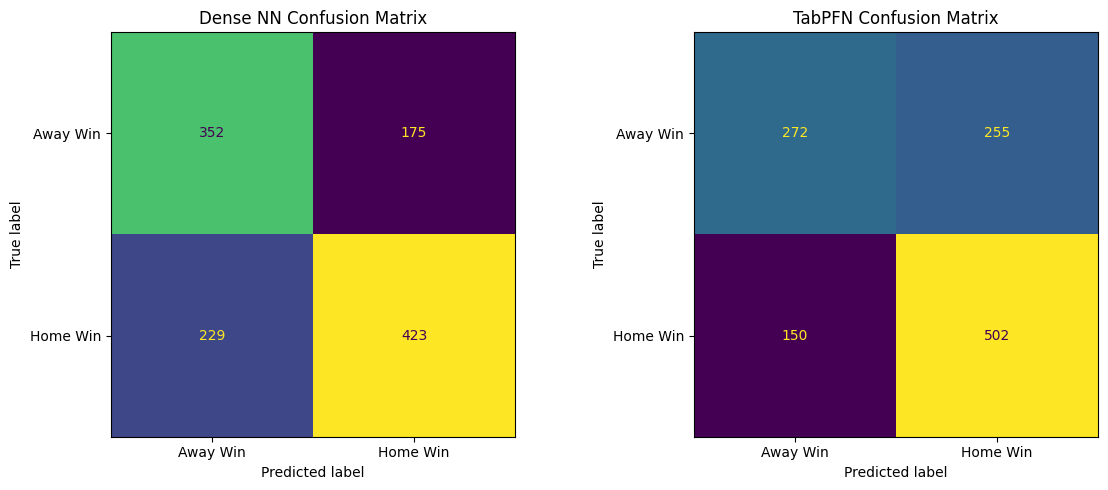

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Dense NN confusion matrix
cm_nn = confusion_matrix(y_test_cls, nn_clf_preds)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=["Away Win", "Home Win"])
disp_nn.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Dense NN Confusion Matrix")

# TabPFN confusion matrix
cm_pfn = confusion_matrix(y_test_cls, pfn_clf_preds)
disp_pfn = ConfusionMatrixDisplay(confusion_matrix=cm_pfn, display_labels=["Away Win", "Home Win"])
disp_pfn.plot(ax=axes[1], colorbar=False)
axes[1].set_title("TabPFN Confusion Matrix")

plt.tight_layout()
plt.show()

## 6. Model Comparison

### 6a. ROC / AUC

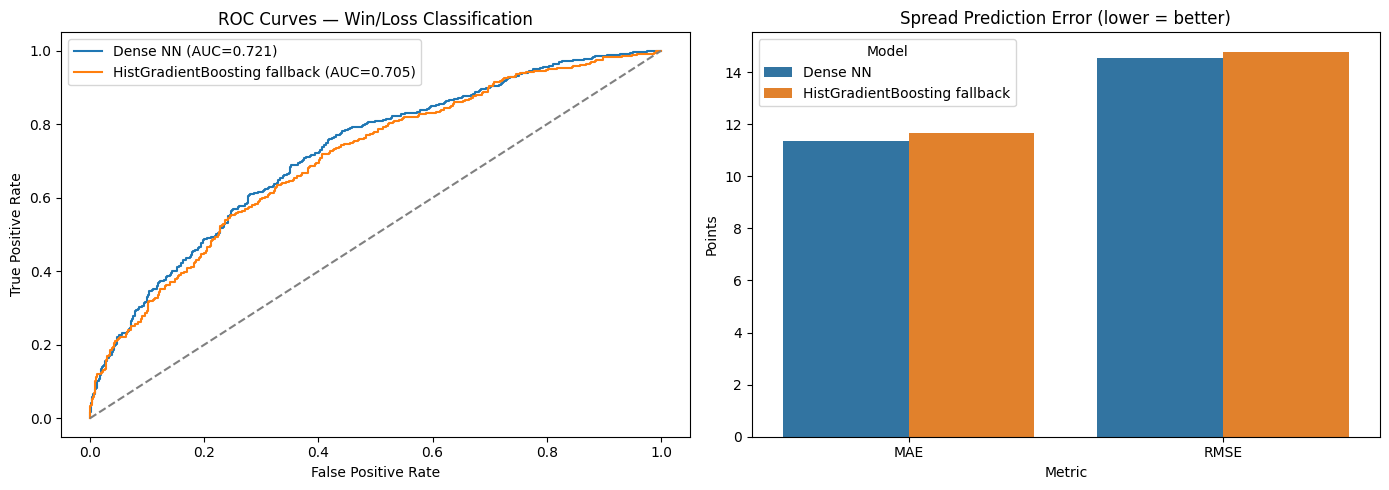


Model                               Cls Acc    ROC AUC   Spread MAE  Spread RMSE
Dense NN                             0.6573     0.7207        11.36        14.56
HistGradientBoosting fallback        0.6565     0.7050        11.66        14.78


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
ax = axes[0]
for name, probs in [('Dense NN', nn_clf_probs), (TABULAR_MODEL_NAME, pfn_clf_probs)]:
    fpr, tpr, _ = roc_curve(y_test_cls, probs)
    auc = roc_auc_score(y_test_cls, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'--', color='gray')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Win/Loss Classification'); ax.legend()

# Spread prediction comparison
ax = axes[1]
results = pd.DataFrame({
    'Model': ['Dense NN', 'Dense NN', TABULAR_REG_MODEL_NAME, TABULAR_REG_MODEL_NAME],
    'Metric': ['MAE', 'RMSE', 'MAE', 'RMSE'],
    'Value': [
        mean_absolute_error(y_test_spread, nn_spread_preds),
        np.sqrt(mean_squared_error(y_test_spread, nn_spread_preds)),
        mean_absolute_error(y_test_spread, pfn_spread_preds),
        np.sqrt(mean_squared_error(y_test_spread, pfn_spread_preds)),
    ]
})
sns.barplot(data=results, x='Metric', y='Value', hue='Model', ax=ax)
ax.set_title('Spread Prediction Error (lower = better)')
ax.set_ylabel('Points')

plt.tight_layout()
plt.show()


print('\n' + '='*72)
print(f'{"Model":<32} {"Cls Acc":>10} {"ROC AUC":>10} {"Spread MAE":>12} {"Spread RMSE":>12}')
print('='*72)
print(f'{"Dense NN":<32} {accuracy_score(y_test_cls, nn_clf_preds):>10.4f} {roc_auc_score(y_test_cls, nn_clf_probs):>10.4f} {mean_absolute_error(y_test_spread, nn_spread_preds):>12.2f} {np.sqrt(mean_squared_error(y_test_spread, nn_spread_preds)):>12.2f}')
print(f'{TABULAR_MODEL_NAME:<32} {accuracy_score(y_test_cls, pfn_clf_preds):>10.4f} {roc_auc_score(y_test_cls, pfn_clf_probs):>10.4f} {mean_absolute_error(y_test_spread, pfn_spread_preds):>12.2f} {np.sqrt(mean_squared_error(y_test_spread, pfn_spread_preds)):>12.2f}')
print('='*72)


### 6b. NN Training Curves


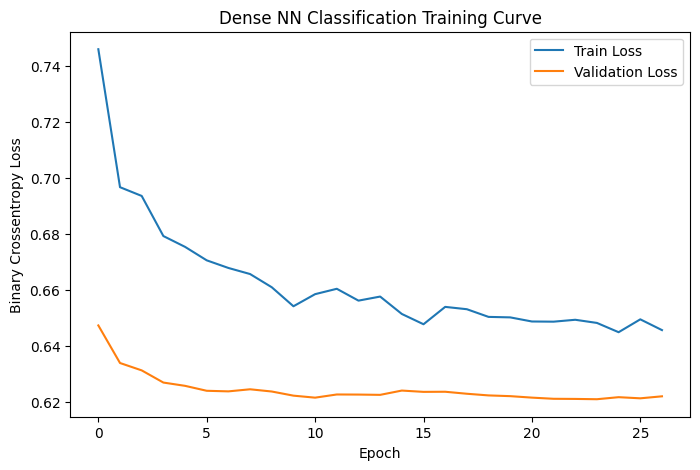

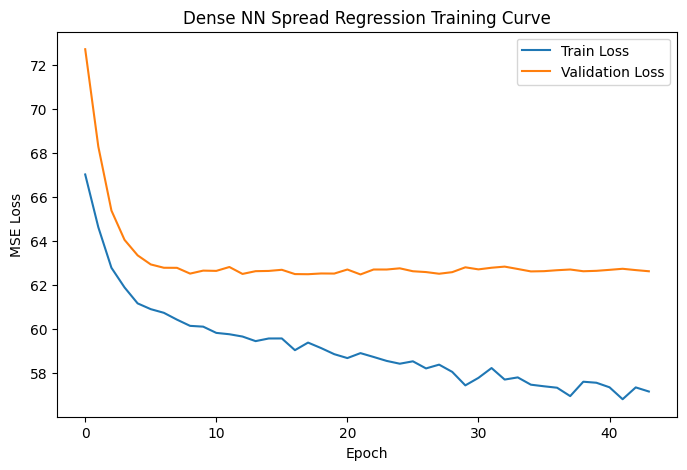

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_clf.history["loss"], label="Train Loss")
plt.plot(history_clf.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Dense NN Classification Training Curve")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_spread.history["loss"], label="Train Loss")
plt.plot(history_spread.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Dense NN Spread Regression Training Curve")
plt.legend()
plt.show()

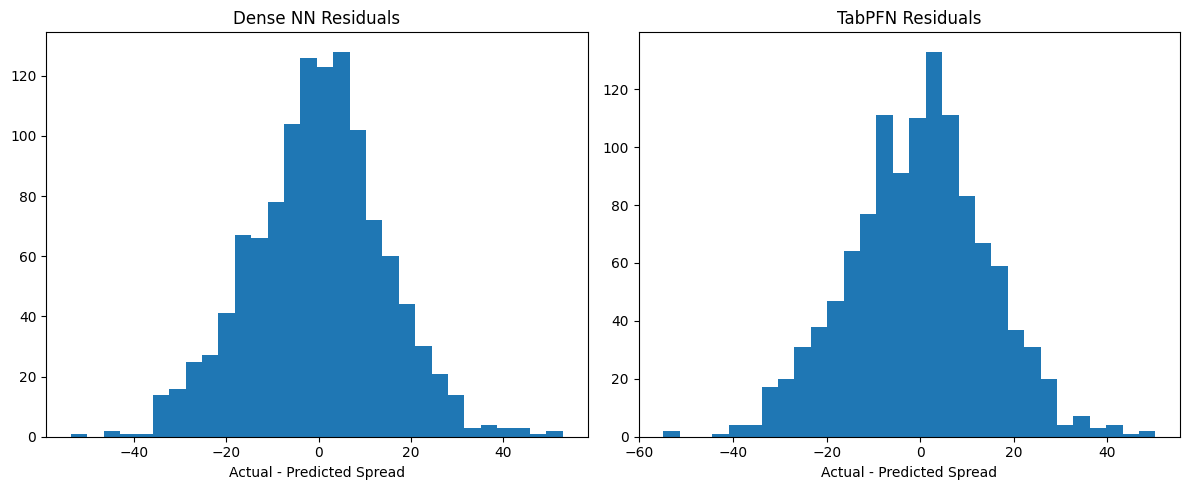

In [ ]:
nn_resid = y_test_spread - nn_spread_preds
pfn_resid = y_test_spread - pfn_spread_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(nn_resid, bins=30)
axes[0].set_title("Dense NN Residuals")
axes[0].set_xlabel("Actual - Predicted Spread")

axes[1].hist(pfn_resid, bins=30)
axes[1].set_title("TabPFN Residuals")
axes[1].set_xlabel("Actual - Predicted Spread")

plt.tight_layout()
plt.show()

## 7. Matchup Predictor
Feed in two team abbreviations and get win probability + predicted spread.

In [ ]:

def get_team_current_features(team_abbr, team_game_df, feature_cols):
    """
    Get the most recent pre-game rolling features for a team.
    Uses the latest available game in chronological order.
    """
    sort_cols = ['SEASON', 'GAME_ID']
    team_data = (
        team_game_df[team_game_df['TEAM'] == team_abbr]
        .sort_values(sort_cols)
        .dropna(subset=['R_PTS'])
    )

    if team_data.empty:
        available = ', '.join(sorted(team_game_df['TEAM'].dropna().unique()))
        raise ValueError(f'No data found for team {team_abbr}. Available teams: {available}')

    latest = team_data.iloc[-1]
    return {col: latest[col] for col in feature_cols}


def _predict_tabular_proba(model, X_pred_df):
    if hasattr(model, 'predict_proba'):
        return float(model.predict_proba(X_pred_df.values)[:, 1][0])
    return np.nan


def predict_matchup(home_team, away_team, team_game_df=team_game_clean, models=None):
    """
    Predict the outcome of a matchup between two team abbreviations.
    Uses the most recent rolling stats for each team.
    """
    if models is None:
        models = {
            'nn_clf': globals().get('nn_clf'),
            'nn_spread': globals().get('nn_spread'),
            'tabular_clf': globals().get('pfn_clf'),
            'tabular_spread': globals().get('pfn_reg'),
        }

    missing_models = [name for name, model in models.items() if model is None]
    if missing_models:
        raise RuntimeError(f'Models not trained yet: {missing_models}. Run the model training cells first.')

    feat_cols = [c for c in team_game_df.columns if c.startswith('R_')] + [
        'LAST10_WINS', 'MISSING_USG', 'MISSING_PPG', 'MISSING_KEY_COUNT'
    ]

    home_feats = get_team_current_features(home_team, team_game_df, feat_cols)
    away_feats = get_team_current_features(away_team, team_game_df, feat_cols)

    diff = {f'D_{c}': home_feats[c] - away_feats[c] for c in feat_cols}
    diff['HOME_ADV'] = 1

    X_pred_df = pd.DataFrame([diff]).reindex(columns=FEATURES, fill_value=0)
    X_pred_sc = scaler.transform(X_pred_df.values)

    nn_win_prob = float(models['nn_clf'].predict(X_pred_sc, verbose=0)[0][0])
    nn_spread_pred = float(models['nn_spread'].predict(X_pred_sc, verbose=0)[0][0])

    tabular_win_prob = _predict_tabular_proba(models['tabular_clf'], X_pred_df)
    tabular_spread_pred = float(np.asarray(models['tabular_spread'].predict(X_pred_df.values)).reshape(-1)[0])

    model_probs = [nn_win_prob]
    if pd.notna(tabular_win_prob):
        model_probs.append(tabular_win_prob)
    model_spreads = [nn_spread_pred, tabular_spread_pred]

    avg_prob = float(np.mean(model_probs))
    avg_spread = float(np.mean(model_spreads))

    tabular_name = globals().get('TABULAR_MODEL_NAME', 'Tabular model')
    print(f'\n{"="*55}')
    print(f'  MATCHUP: {home_team} (home) vs {away_team} (away)')
    print(f'{"="*55}')
    print(f'\n  {"Model":<24} {"Home Win %":>12} {"Pred Spread":>12}')
    print(f'  {"-"*50}')
    print(f'  {"Dense NN":<24} {nn_win_prob:>11.1%} {nn_spread_pred:>+12.1f}')
    print(f'  {tabular_name:<24} {tabular_win_prob:>11.1%} {tabular_spread_pred:>+12.1f}')
    print(f'  {"-"*50}')
    print(f'  {"ENSEMBLE":<24} {avg_prob:>11.1%} {avg_spread:>+12.1f}')
    print(f'\n  Predicted winner: {home_team if avg_prob > 0.5 else away_team}')
    print(f'{"="*55}\n')

    return {
        'home_team': home_team,
        'away_team': away_team,
        'nn_prob': nn_win_prob,
        'nn_spread': nn_spread_pred,
        'tabular_prob': tabular_win_prob,
        'tabular_spread': tabular_spread_pred,
        'ensemble_prob': avg_prob,
        'ensemble_spread': avg_spread,
    }


### Try some matchups!

In [ ]:
# available teams
teams = sorted(team_game_clean['TEAM'].unique())
print('Available teams:', teams)
print(f'({len(teams)} teams)')

Available teams: ['ATL', 'BKN', 'BOS', 'CHA', 'CHI', 'CLE', 'DAL', 'DEN', 'DET', 'GSW', 'HOU', 'IND', 'LAC', 'LAL', 'MEM', 'MIA', 'MIL', 'MIN', 'NOP', 'NYK', 'OKC', 'ORL', 'PHI', 'PHX', 'POR', 'SAC', 'SAS', 'TOR', 'UTA', 'WAS']
(30 teams)


# 8. Odds API Integration


In [ ]:

import requests

os.environ['ODDS_API_KEY'] = '1fc26aea42d75d09be22cab6f9814425'
ODDS_API_KEY = os.getenv('ODDS_API_KEY', '')
SPORT = 'basketball_nba'
REGIONS = 'us'
MARKETS = 'h2h,spreads'
ODDS_FORMAT = 'american'

TEAM_NAME_MAP = {
    'ATL': 'Atlanta Hawks', 'BOS': 'Boston Celtics', 'BKN': 'Brooklyn Nets',
    'CHA': 'Charlotte Hornets', 'CHI': 'Chicago Bulls', 'CLE': 'Cleveland Cavaliers',
    'DAL': 'Dallas Mavericks', 'DEN': 'Denver Nuggets', 'DET': 'Detroit Pistons',
    'GSW': 'Golden State Warriors', 'HOU': 'Houston Rockets', 'IND': 'Indiana Pacers',
    'LAC': 'LA Clippers', 'LAL': 'Los Angeles Lakers', 'MEM': 'Memphis Grizzlies',
    'MIA': 'Miami Heat', 'MIL': 'Milwaukee Bucks', 'MIN': 'Minnesota Timberwolves',
    'NOP': 'New Orleans Pelicans', 'NYK': 'New York Knicks', 'OKC': 'Oklahoma City Thunder',
    'ORL': 'Orlando Magic', 'PHI': 'Philadelphia 76ers', 'PHX': 'Phoenix Suns',
    'POR': 'Portland Trail Blazers', 'SAC': 'Sacramento Kings', 'SAS': 'San Antonio Spurs',
    'TOR': 'Toronto Raptors', 'UTA': 'Utah Jazz', 'WAS': 'Washington Wizards'
}
TEAM_ABBR_MAP = {full: abbr for abbr, full in TEAM_NAME_MAP.items()}


def american_to_implied_prob(odds):
    """Convert American odds to implied probability."""
    if odds is None or pd.isna(odds):
        return np.nan
    odds = float(odds)
    return 100 / (odds + 100) if odds > 0 else abs(odds) / (abs(odds) + 100)


def get_nba_odds(api_key=ODDS_API_KEY, sport=SPORT, regions=REGIONS,
                 markets=MARKETS, odds_format=ODDS_FORMAT):
    """Pull current NBA odds from The Odds API. Returns raw JSON."""
    if not api_key:
        raise ValueError("Missing ODDS_API_KEY. Set os.environ['ODDS_API_KEY'] before calling get_nba_odds().")

    url = f'https://api.the-odds-api.com/v4/sports/{sport}/odds'
    params = {
        'apiKey': api_key,
        'regions': regions,
        'markets': markets,
        'oddsFormat': odds_format,
        'dateFormat': 'iso'
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    return response.json()


def parse_odds_json(odds_json):
    """Flatten Odds API JSON into one row per bookmaker per game."""
    rows = []

    for game in odds_json:
        game_id = game.get('id')
        commence_time = game.get('commence_time')
        home_team = game.get('home_team')
        away_team = game.get('away_team')
        bookmakers = game.get('bookmakers', [])

        for book in bookmakers:
            row = {
                'event_id': game_id,
                'commence_time': commence_time,
                'home_team': home_team,
                'away_team': away_team,
                'home_abbr': TEAM_ABBR_MAP.get(home_team),
                'away_abbr': TEAM_ABBR_MAP.get(away_team),
                'bookmaker': book.get('title'),
                'home_ml': np.nan,
                'away_ml': np.nan,
                'home_spread': np.nan,
                'away_spread': np.nan,
                'home_spread_price': np.nan,
                'away_spread_price': np.nan,
            }

            for market in book.get('markets', []):
                key = market.get('key')
                outcomes = market.get('outcomes', [])

                if key == 'h2h':
                    for outcome in outcomes:
                        if outcome.get('name') == home_team:
                            row['home_ml'] = outcome.get('price')
                        elif outcome.get('name') == away_team:
                            row['away_ml'] = outcome.get('price')

                elif key == 'spreads':
                    for outcome in outcomes:
                        if outcome.get('name') == home_team:
                            row['home_spread'] = outcome.get('point')
                            row['home_spread_price'] = outcome.get('price')
                        elif outcome.get('name') == away_team:
                            row['away_spread'] = outcome.get('point')
                            row['away_spread_price'] = outcome.get('price')

            rows.append(row)

    return pd.DataFrame(rows)


def get_best_market_lines(odds_df):
    """Summarize each game to best available moneyline and representative home spread."""
    if odds_df.empty:
        return odds_df

    best_rows = []
    grouped = odds_df.groupby([
        'event_id', 'home_team', 'away_team', 'home_abbr', 'away_abbr', 'commence_time'
    ], dropna=False)

    for keys, g in grouped:
        event_id, home_team, away_team, home_abbr, away_abbr, commence_time = keys

        home_ml_idx = g['home_ml'].astype(float).idxmax() if g['home_ml'].notna().any() else None
        away_ml_idx = g['away_ml'].astype(float).idxmax() if g['away_ml'].notna().any() else None

        spread_subset = g[g['home_spread'].notna()].copy()
        if not spread_subset.empty:
            spread_idx = spread_subset['home_spread_price'].astype(float).idxmax()
            best_spread = spread_subset.loc[spread_idx, 'home_spread']
            best_spread_price = spread_subset.loc[spread_idx, 'home_spread_price']
            best_spread_book = spread_subset.loc[spread_idx, 'bookmaker']
        else:
            best_spread = np.nan
            best_spread_price = np.nan
            best_spread_book = None

        best_rows.append({
            'event_id': event_id,
            'commence_time': commence_time,
            'home_team': home_team,
            'away_team': away_team,
            'home_abbr': home_abbr,
            'away_abbr': away_abbr,
            'best_home_ml': g.loc[home_ml_idx, 'home_ml'] if home_ml_idx is not None else np.nan,
            'best_home_ml_book': g.loc[home_ml_idx, 'bookmaker'] if home_ml_idx is not None else None,
            'best_away_ml': g.loc[away_ml_idx, 'away_ml'] if away_ml_idx is not None else np.nan,
            'best_away_ml_book': g.loc[away_ml_idx, 'bookmaker'] if away_ml_idx is not None else None,
            'market_home_spread': best_spread,
            'market_home_spread_price': best_spread_price,
            'market_spread_book': best_spread_book
        })

    return pd.DataFrame(best_rows)


def evaluate_betting_edge(home_team, away_team, odds_summary_df,
                          min_prob_edge=0.03, min_spread_edge=1.5, verbose=True):
    """Compare model predictions to sportsbook market for abbreviation inputs, e.g. BOS/LAL."""
    model_pred = predict_matchup(home_team, away_team)

    row = odds_summary_df[
        (odds_summary_df['home_abbr'] == home_team) &
        (odds_summary_df['away_abbr'] == away_team)
    ]

    if row.empty:
        print(f'No sportsbook odds found for {away_team} @ {home_team}')
        return None

    row = row.iloc[0]
    model_home_prob = model_pred['ensemble_prob']
    model_home_spread = model_pred['ensemble_spread']

    home_ml = row['best_home_ml']
    away_ml = row['best_away_ml']
    home_imp_prob = american_to_implied_prob(home_ml)
    away_imp_prob = american_to_implied_prob(away_ml)

    home_prob_edge = model_home_prob - home_imp_prob if pd.notna(home_imp_prob) else np.nan
    away_model_prob = 1 - model_home_prob
    away_prob_edge = away_model_prob - away_imp_prob if pd.notna(away_imp_prob) else np.nan

    market_home_spread = row['market_home_spread']
    spread_edge = model_home_spread - market_home_spread if pd.notna(market_home_spread) else np.nan

    ml_recommendation = 'No bet'
    if pd.notna(home_prob_edge) and home_prob_edge >= min_prob_edge:
        ml_recommendation = f'Bet HOME moneyline ({home_team}) at {row["best_home_ml_book"]}'
    elif pd.notna(away_prob_edge) and away_prob_edge >= min_prob_edge:
        ml_recommendation = f'Bet AWAY moneyline ({away_team}) at {row["best_away_ml_book"]}'

    spread_recommendation = 'No bet'
    if pd.notna(spread_edge):
        if spread_edge >= min_spread_edge:
            spread_recommendation = f'Bet HOME spread ({home_team}) at {row["market_spread_book"]}'
        elif spread_edge <= -min_spread_edge:
            spread_recommendation = f'Bet AWAY spread ({away_team}) at {row["market_spread_book"]}'

    result = {
        'home_team': home_team,
        'away_team': away_team,
        'home_full': row['home_team'],
        'away_full': row['away_team'],
        'commence_time': row['commence_time'],
        'model_home_win_prob': model_home_prob,
        'model_home_spread': model_home_spread,
        'best_home_ml': home_ml,
        'best_home_ml_book': row['best_home_ml_book'],
        'best_away_ml': away_ml,
        'best_away_ml_book': row['best_away_ml_book'],
        'market_home_spread': market_home_spread,
        'market_spread_book': row['market_spread_book'],
        'home_prob_edge': home_prob_edge,
        'away_prob_edge': away_prob_edge,
        'spread_edge': spread_edge,
        'moneyline_recommendation': ml_recommendation,
        'spread_recommendation': spread_recommendation
    }

    if verbose:
        print('\n' + '='*65)
        print(f'BETTING EDGE REPORT: {away_team} @ {home_team}')
        print('='*65)
        print(f'Model home win probability: {model_home_prob:.3f}')
        print(f'Model predicted spread:     {model_home_spread:+.2f}')
        print(f'Best home ML:               {home_ml} ({row["best_home_ml_book"]})')
        print(f'Best away ML:               {away_ml} ({row["best_away_ml_book"]})')
        print(f'Market home spread:         {market_home_spread:+.2f} ({row["market_spread_book"]})')
        print(f'Home ML edge:               {home_prob_edge:.3f}' if pd.notna(home_prob_edge) else 'Home ML edge: N/A')
        print(f'Away ML edge:               {away_prob_edge:.3f}' if pd.notna(away_prob_edge) else 'Away ML edge: N/A')
        print(f'Spread edge:                {spread_edge:+.2f}' if pd.notna(spread_edge) else 'Spread edge: N/A')
        print(f'Moneyline recommendation:   {ml_recommendation}')
        print(f'Spread recommendation:      {spread_recommendation}')
        print('='*65)

    return result


In [ ]:


try:
    odds_json = get_nba_odds()
    odds_df = parse_odds_json(odds_json)
    odds_summary = get_best_market_lines(odds_df)
    print(f'Loaded odds for {len(odds_summary):,} NBA games.')
    display(odds_summary.head())
except Exception as exc:
    odds_json = []
    odds_df = pd.DataFrame()
    odds_summary = pd.DataFrame()
    print(f'Skipping live odds pull: {type(exc).__name__}: {exc}')


Loaded odds for 8 NBA games.


,event_id,commence_time,home_team,away_team,home_abbr,away_abbr,best_home_ml,best_home_ml_book,best_away_ml,best_away_ml_book,market_home_spread,market_home_spread_price,market_spread_book
0,04e3ad1ccbad6419ac711ff120fd5cbe,2026-04-20T01:18:00Z,San Antonio Spurs,Portland Trail Blazers,SAS,POR,-2500.0,FanDuel,1100.0,DraftKings,-15.5,-110,Bovada
1,0ce48ecb61f40bc3bd784adfe7f8e811,2026-04-23T01:40:00Z,Oklahoma City Thunder,Phoenix Suns,OKC,PHX,-1650.0,DraftKings,1092.0,LowVig.ag,-17.0,-101,LowVig.ag
2,273905d6a4ae9217ec0734b66a0eb28b,2026-04-20T23:10:00Z,Cleveland Cavaliers,Toronto Raptors,CLE,TOR,-340.0,DraftKings,301.0,LowVig.ag,-8.5,-110,DraftKings
3,a1b444bd00a27cbae3cf7ca3bf75a3f0,2026-04-21T00:10:00Z,New York Knicks,Atlanta Hawks,NYK,ATL,-222.0,MyBookie.ag,195.0,DraftKings,-5.5,-106,LowVig.ag
4,a52365fe7f7123df1c4220d9591a6da2,2026-04-21T02:40:00Z,Denver Nuggets,Minnesota Timberwolves,DEN,MIN,-245.0,DraftKings,220.0,FanDuel,-6.5,-110,DraftKings


## 9. Predict Full Slate
Predict outcomes for a list of games at once.

In [ ]:

def predict_slate(matchup_list):
    """
    Predict a full slate of games.
    matchup_list: list of (home_team, away_team) abbreviation tuples.
    """
    results = []
    for home, away in matchup_list:
        try:
            r = predict_matchup(home, away)
            results.append(r)
        except Exception as e:
            print(f'Error for {away} @ {home}: {e}')
    return pd.DataFrame(results)

# Example slate
slate = [
    ('BOS', 'MIA'),
    ('LAL', 'GSW'),
    ('NYK', 'PHI'),
    ('DEN', 'MIN'),
    ('OKC', 'DAL'),
]

slate_df = predict_slate(slate)
slate_df



  MATCHUP: BOS (home) vs MIA (away)

  Model                      Home Win %  Pred Spread
  --------------------------------------------------
  Dense NN                       59.0%         +5.2
  HistGradientBoosting fallback       60.0%         +2.7
  --------------------------------------------------
  ENSEMBLE                       59.5%         +4.0

  Predicted winner: BOS


  MATCHUP: LAL (home) vs GSW (away)

  Model                      Home Win %  Pred Spread
  --------------------------------------------------
  Dense NN                       69.7%         +8.0
  HistGradientBoosting fallback       71.3%         +6.4
  --------------------------------------------------
  ENSEMBLE                       70.5%         +7.2

  Predicted winner: LAL


  MATCHUP: NYK (home) vs PHI (away)

  Model                      Home Win %  Pred Spread
  --------------------------------------------------
  Dense NN                       60.6%         +7.7
  HistGradientBoosting fallback     

,home_team,away_team,nn_prob,nn_spread,tabular_prob,tabular_spread,ensemble_prob,ensemble_spread
0,BOS,MIA,0.589846,5.207410,0.600342,2.740592,0.595094,3.974001
1,LAL,GSW,0.696958,8.012928,0.713128,6.373868,0.705043,7.193398
2,NYK,PHI,0.605944,7.739346,0.692356,7.401802,0.649150,7.570574
3,DEN,MIN,0.659568,6.127244,0.756035,6.836164,0.707801,6.481704
4,OKC,DAL,0.726447,7.306237,0.692996,5.492057,0.709721,6.399147


# 9. Model v Odds Market

In [ ]:

print(f'Team mappings loaded: {len(TEAM_NAME_MAP)} teams')


Team mappings loaded: 30 teams



  MATCHUP: SAS (home) vs POR (away)

  Model                      Home Win %  Pred Spread
  --------------------------------------------------
  Dense NN                       68.8%         +8.7
  HistGradientBoosting fallback       76.0%        +14.1
  --------------------------------------------------
  ENSEMBLE                       72.4%        +11.4

  Predicted winner: SAS


  MATCHUP: OKC (home) vs PHX (away)

  Model                      Home Win %  Pred Spread
  --------------------------------------------------
  Dense NN                       77.9%        +10.8
  HistGradientBoosting fallback       79.1%         +9.1
  --------------------------------------------------
  ENSEMBLE                       78.5%        +10.0

  Predicted winner: OKC


  MATCHUP: CLE (home) vs TOR (away)

  Model                      Home Win %  Pred Spread
  --------------------------------------------------
  Dense NN                       53.6%         +1.0
  HistGradientBoosting fallback     

,home_team,away_team,home_full,away_full,commence_time,model_home_win_prob,model_home_spread,best_home_ml,best_home_ml_book,best_away_ml,best_away_ml_book,market_home_spread,market_spread_book,home_prob_edge,away_prob_edge,spread_edge,moneyline_recommendation,spread_recommendation,abs_spread_edge,best_prob_edge
0,OKC,PHX,Oklahoma City Thunder,Phoenix Suns,2026-04-23T01:40:00Z,0.785186,9.956248,-1650.0,DraftKings,1092.0,LowVig.ag,-17.0,LowVig.ag,-0.157672,0.130922,26.956248,Bet AWAY moneyline (PHX) at LowVig.ag,Bet HOME spread (OKC) at LowVig.ag,26.956248,0.130922
1,SAS,POR,San Antonio Spurs,Portland Trail Blazers,2026-04-20T01:18:00Z,0.723612,11.376188,-2500.0,FanDuel,1100.0,DraftKings,-15.5,Bovada,-0.237926,0.193055,26.876188,Bet AWAY moneyline (POR) at DraftKings,Bet HOME spread (SAS) at Bovada,26.876188,0.193055
2,BOS,PHI,Boston Celtics,Philadelphia 76ers,2026-04-21T23:10:00Z,0.618837,5.005390,-720.0,FanDuel,600.0,DraftKings,-14.5,DraftKings,-0.259212,0.238306,19.505390,Bet AWAY moneyline (PHI) at DraftKings,Bet HOME spread (BOS) at DraftKings,19.505390,0.238306
3,DET,ORL,Detroit Pistons,Orlando Magic,2026-04-22T23:00:00Z,0.768552,7.572528,-395.0,DraftKings,350.0,FanDuel,-9.5,DraftKings,-0.029428,0.009226,17.072528,No bet,Bet HOME spread (DET) at DraftKings,17.072528,0.009226
4,NYK,ATL,New York Knicks,Atlanta Hawks,2026-04-21T00:10:00Z,0.779942,11.045315,-222.0,MyBookie.ag,195.0,DraftKings,-5.5,LowVig.ag,0.090501,-0.118925,16.545315,Bet HOME moneyline (NYK) at MyBookie.ag,Bet HOME spread (NYK) at LowVig.ag,16.545315,0.090501
5,DEN,MIN,Denver Nuggets,Minnesota Timberwolves,2026-04-21T02:40:00Z,0.707801,6.481704,-245.0,DraftKings,220.0,FanDuel,-6.5,DraftKings,-0.002343,-0.020301,12.981704,No bet,Bet HOME spread (DEN) at DraftKings,12.981704,-0.002343
6,CLE,TOR,Cleveland Cavaliers,Toronto Raptors,2026-04-20T23:10:00Z,0.584716,2.900653,-340.0,DraftKings,301.0,LowVig.ag,-8.5,DraftKings,-0.188011,0.165908,11.400653,Bet AWAY moneyline (TOR) at LowVig.ag,Bet HOME spread (CLE) at DraftKings,11.400653,0.165908
7,LAL,HOU,Los Angeles Lakers,Houston Rockets,2026-04-22T02:40:00Z,0.322234,-1.091077,165.0,Bovada,-175.0,DraftKings,5.0,LowVig.ag,-0.055125,0.041403,-6.091077,Bet AWAY moneyline (HOU) at DraftKings,Bet AWAY spread (HOU) at LowVig.ag,6.091077,0.041403


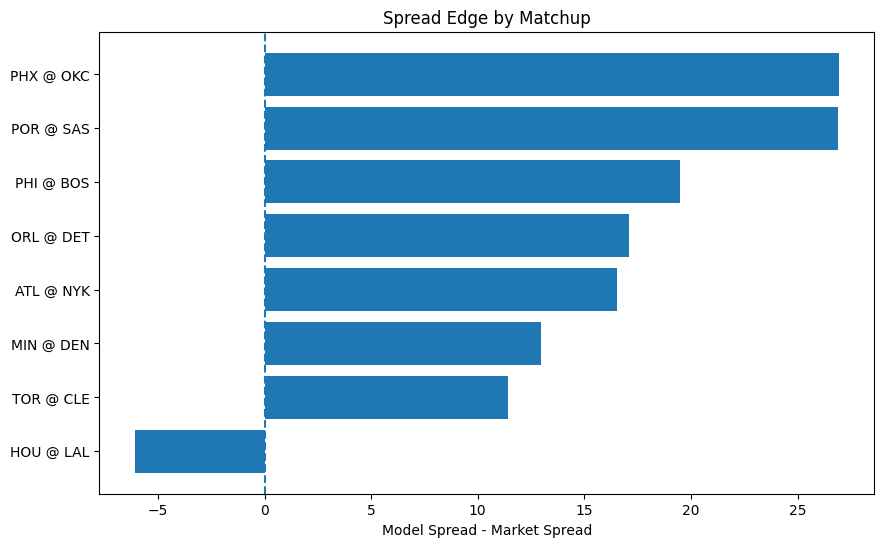

In [ ]:

def build_edge_slate(odds_summary_df, min_prob_edge=0.03, min_spread_edge=1.5):
    """Evaluate every game available in odds_summary_df."""
    if odds_summary_df is None or odds_summary_df.empty:
        print('No odds_summary data available. Run the odds pull cell after setting ODDS_API_KEY.')
        return pd.DataFrame()

    results = []
    for _, row in odds_summary_df.dropna(subset=['home_abbr', 'away_abbr']).iterrows():
        result = evaluate_betting_edge(
            row['home_abbr'],
            row['away_abbr'],
            odds_summary_df,
            min_prob_edge=min_prob_edge,
            min_spread_edge=min_spread_edge,
            verbose=False
        )
        if result is not None:
            results.append(result)

    edge_slate_df = pd.DataFrame(results)
    if edge_slate_df.empty:
        print('No matching model/odds games found.')
        return edge_slate_df

    edge_slate_df['abs_spread_edge'] = edge_slate_df['spread_edge'].abs()
    edge_slate_df['best_prob_edge'] = edge_slate_df[['home_prob_edge', 'away_prob_edge']].max(axis=1)
    return edge_slate_df.sort_values(['abs_spread_edge', 'best_prob_edge'], ascending=False).reset_index(drop=True)


edge_slate_df = build_edge_slate(odds_summary)
display(edge_slate_df)

if not edge_slate_df.empty:
    plot_df = edge_slate_df.copy()
    plot_df['matchup'] = plot_df['away_team'] + ' @ ' + plot_df['home_team']

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df['matchup'], plot_df['spread_edge'])
    plt.xlabel('Model Spread - Market Spread')
    plt.title('Spread Edge by Matchup')
    plt.axvline(0, linestyle='--')
    plt.gca().invert_yaxis()
    plt.show()


In [ ]:

evaluation_summary = pd.DataFrame({
    'Model': ['Dense NN', TABULAR_MODEL_NAME],
    'Classification Accuracy': [
        accuracy_score(y_test_cls, nn_clf_preds),
        accuracy_score(y_test_cls, pfn_clf_preds)
    ],
    'ROC AUC': [
        roc_auc_score(y_test_cls, nn_clf_probs),
        roc_auc_score(y_test_cls, pfn_clf_probs)
    ],
    'Spread MAE': [
        mean_absolute_error(y_test_spread, nn_spread_preds),
        mean_absolute_error(y_test_spread, pfn_spread_preds)
    ],
    'Spread RMSE': [
        np.sqrt(mean_squared_error(y_test_spread, nn_spread_preds)),
        np.sqrt(mean_squared_error(y_test_spread, pfn_spread_preds))
    ],
    'Spread R2': [
        r2_score(y_test_spread, nn_spread_preds),
        r2_score(y_test_spread, pfn_spread_preds)
    ]
})

display(evaluation_summary)


,Model,Classification Accuracy,ROC AUC,Spread MAE,Spread RMSE,Spread R2
0,Dense NN,0.657337,0.720673,11.361984,14.555433,0.207734
1,HistGradientBoosting fallback,0.656489,0.705021,11.656844,14.783684,0.182691


## 10. Save Models & Data

In [ ]:

# Save everything to Drive for reuse.
import pickle
import os
save_dir = os.path.join(DATA_DIR, 'models')
os.makedirs(save_dir, exist_ok=True)

nn_clf.save(os.path.join(save_dir, 'nn_classifier.keras'))
nn_spread.save(os.path.join(save_dir, 'nn_spread.keras'))

with open(os.path.join(save_dir, 'tabular_classifier.pkl'), 'wb') as f:
    pickle.dump(pfn_clf, f)
with open(os.path.join(save_dir, 'tabular_regressor.pkl'), 'wb') as f:
    pickle.dump(pfn_reg, f)
with open(os.path.join(save_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(save_dir, 'feature_columns.pkl'), 'wb') as f:
    pickle.dump(FEATURES, f)

# Save the processed matchup data
matchups_sorted.to_csv(os.path.join(DATA_DIR, 'matchup_features.csv'), index=False)
team_game_clean.to_csv(os.path.join(DATA_DIR, 'team_game_features.csv'), index=False)
evaluation_summary.to_csv(os.path.join(save_dir, 'evaluation_summary.csv'), index=False)

print(f'Models and data saved to {save_dir}')
print('Files:', os.listdir(save_dir))


Models and data saved to /content/drive/MyDrive/Modern AI Final Project/nba_data_2/models
Files: ['pfn_classifier.pkl', 'pfn_regressor.pkl', 'tabular_regressor.pkl', 'scaler.pkl', 'tabular_classifier.pkl', 'feature_columns.pkl', 'evaluation_summary.csv', 'nn_classifier.keras', 'nn_spread.keras']
